# ⚛️ Bell Inequality Simulations: Classical LHV vs. Quantum Mechanics

**Author:** Simone Razzetti  

---

## Project Overview
This notebook presents a computational exploration of **Bell's Theorem** through the **CHSH inequality** framework (Clauser, Horne, Shimony, Holt, 1969). 

The CHSH parameter $S$ combines four measurement correlation functions $E(a, b)$:

$$S = |E(a,b) + E(a',b) + E(a,b') - E(a',b')|$$

and  its theoretical limits are
- **Classical Local Hidden Variable (LHV) Bound:** $|S| \leq 2$
- **Quantum Mechanical Bound (Tsirelson's Bound):** $|S| = 2\sqrt{2} \approx 2.828$

This notebook is divided into two main sections:
1. **Classical Model**: Implementation of a deterministic "hidden direction" model.
2. **Quantum Model**: Simulation of entangled qubit pairs ($|\Psi^-\rangle$ singlet state) using Qiskit.

Both sections contrast **statistical limit calculations** (batch processing over fixed angle pairs) with **full experimental simulations** (trial-by-trial random basis selection).

In [1]:
# --- Setup & Imports ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Classical LHV model

## 1. Defining the Local Hidden Variable Model

We adopt the classic **"hidden direction" model** (Bell, 1964). 

- The hidden variable $\lambda \in [0, 2\pi)$ represents a uniform random direction shared between Alice and Bob.
- Alice and Bob measure along angles $\theta_A$ and $\theta_B$ respectively.
- Outcomes are deterministic functions yielding binary measurements $A, B \in \{+1, -1\}$:

$$A(\theta_A, \lambda) = \operatorname{sign}(\cos(\lambda - \theta_A))$$
$$B(\theta_B, \lambda) = -\operatorname{sign}(\cos(\lambda - \theta_B))$$

The "-" is related to the anticorrelated outcomes for the singlet state measurements. Notice if Alice and Bob measures along the same axis, for the singlet state the outcomes must be anticorrelated.

In [14]:
def A(angle: float, lam: float):
    """
    Simulates Alice's measurement: the outcome is determined by the 
    projection of the hidden variable 'lam' onto the measurement axis 'angle'
    """
    return np.sign(np.cos(lam - angle))

def B(angle: float, lam: float):
    """
    Simulates Bob's measurement: the outcome is determined by the 
    negative projection of the hidden variable 'lam' onto the measurement axis 'angle'
    """
    return -np.sign(np.cos(lam - angle))

# Quick test for a single hidden variable lambda = pi/6 and measurement angle = 0
lam_test = np.pi / 6
print(f"Test lambda = pi/6 | Alice (angle=0): {A(0, lam_test)}, Bob (angle=0): {B(0, lam_test)}")

Test lambda = pi/6 | Alice (angle=0): 1.0, Bob (angle=0): -1.0


## 2. Calculating Correlators $E(a, b)$ in the Statistical Limit

The correlation function $E(a, b)$ measures the expected value of the product of outcomes $A(a, \lambda) \cdot B(b, \lambda)$:

$$E(a, b) = \int_{0}^{2\pi} A(a, \lambda) B(b, \lambda) \rho(\lambda) d\lambda$$

Assuming a uniform distribution $\rho(\lambda) = \frac{1}{2\pi}$, we estimate $E(a, b)$ via Monte Carlo integration over $N$ samples.

In [15]:
def get_E_classical(a, b, n_samples=100000):
    """
    Computes the expectation value E(a, b) by averaging the product 
    of local outcomes over the hidden variable distribution, assuming a uniform distribution.
    """
    # Suppose lambda is uniformly distributed in [0, 2pi]
    lam = np.random.uniform(0, 2*np.pi, n_samples)
    return np.mean(A(a, lam) * B(b, lam))

# Test correlation for parallel and orthogonal detectors
print(f"E(0, 0)      [Parallel]   = {get_E_classical(0, 0):.4f} (Expected: -1.0)")
print(f"E(0, pi/2)   [Orthogonal] = {get_E_classical(0, np.pi/2):.4f} (Expected: 0.0)")

E(0, 0)      [Parallel]   = -1.0000 (Expected: -1.0)
E(0, pi/2)   [Orthogonal] = -0.0034 (Expected: 0.0)


## 3. CHSH Inequality Evaluation ($S$-parameter)

The CHSH parameter $S$ combines four measurement configurations:

$$S = |E(a,b) + E(a',b) + E(a,b') - E(a',b')|$$

For any LHV model, **Bell's theorem** mandates that $|S| \leq 2$. 

We evaluate $S$ using standard optimal measurement settings:
- Alice: $a = 0$, $a' = \pi/2$ ($90^\circ$)
- Bob: $b = \pi/4$ ($45^\circ$), $b' = -\pi/4$ ($-45^\circ$)

In [16]:
def chsh_classical(a=0.0, ap=np.pi/2, b=np.pi/4, bp=-np.pi/4, n_samples=100000) -> float:
    """
    Calculates CHSH S-value evaluating four correlators directly.
    """
    E_ab   = get_E_classical(a, b, n_samples)
    E_apb  = get_E_classical(ap, b, n_samples)
    E_abp  = get_E_classical(a, bp, n_samples)
    E_apbp = get_E_classical(ap, bp, n_samples)

    S = abs(E_ab + E_apb + E_abp - E_apbp)
    
    print(f"E(a, b)   = {E_ab:+.4f}")
    print(f"E(a', b)  = {E_apb:+.4f}")
    print(f"E(a, b')  = {E_abp:+.4f}")
    print(f"E(a', b') = {E_apbp:+.4f}")
    
    return S

print("--- Direct Statistical Calculation ---")
S_direct = chsh_classical()
print(f"\nResulting CHSH S parameter: {S_direct:.4f} (LHV Bound: |S| <= 2)")

--- Direct Statistical Calculation ---
E(a, b)   = -0.5009
E(a', b)  = -0.5024
E(a, b')  = -0.5025
E(a', b') = +0.4980

Resulting CHSH S parameter: 2.0038 (LHV Bound: |S| <= 2)


## 4. Full Experimental Protocol Simulation

In a real laboratory setting, Alice and Bob cannot fix angles for each batch in advance if they want to guarantee strict locality. 

For **each event (trial)**:
1. A hidden variable $\lambda$ is emitted.
2. Alice randomly chooses between $a$ and $a'$.
3. Bob randomly chooses between $b$ and $b'$.
4. Outcomes are recorded and sorted into the four correlator bins post-experimentally.

In [17]:
def simulate_classical_experiment(n_trials=100000, a=0.0, ap=np.pi/2, b=np.pi/4, bp=-np.pi/4):
    """
    Simulates a trial-by-trial CHSH experiment with random basis choices.
    """
    sums   = {'a_b': 0, 'a_bp': 0, 'ap_b': 0, 'ap_bp': 0}
    counts = {'a_b': 0, 'a_bp': 0, 'ap_b': 0, 'ap_bp': 0}

    for _ in tqdm(range(n_trials), desc="Simulating trials"):
        alice_angle = np.random.choice([a, ap])
        bob_angle   = np.random.choice([b, bp])

        alice_key = 'a' if alice_angle == a else 'ap'
        bob_key   = 'b' if bob_angle == b else 'bp'
        key = f"{alice_key}_{bob_key}"

        lam = np.random.uniform(0, 2 * np.pi)
        outcome = A(alice_angle, lam) * B(bob_angle, lam)

        sums[key]   += outcome
        counts[key] += 1

    E_ab   = sums['a_b']   / counts['a_b']
    E_abp  = sums['a_bp']  / counts['a_bp']
    E_apb  = sums['ap_b']  / counts['ap_b']
    E_apbp = sums['ap_bp'] / counts['ap_bp']

    S = abs(E_ab + E_apb + E_abp - E_apbp)
    
    return S

print("--- Running Event-by-Event Simulation ---")
S_sim = simulate_classical_experiment(n_trials=200000)
print(f"\nFinal S (Full Lab Simulation): {S_sim:.4f}")

--- Running Event-by-Event Simulation ---


Simulating trials: 100%|██████████| 200000/200000 [00:05<00:00, 33523.16it/s]


Final S (Full Lab Simulation): 1.9999


## extra: Convergence Analysis

Let's observe how the empirical parameter $S$ converges to the theoretical classical bound as the number of experimental trials increases.

Simulating trials: 100%|██████████| 100000/100000 [00:03<00:00, 32519.32it/s]


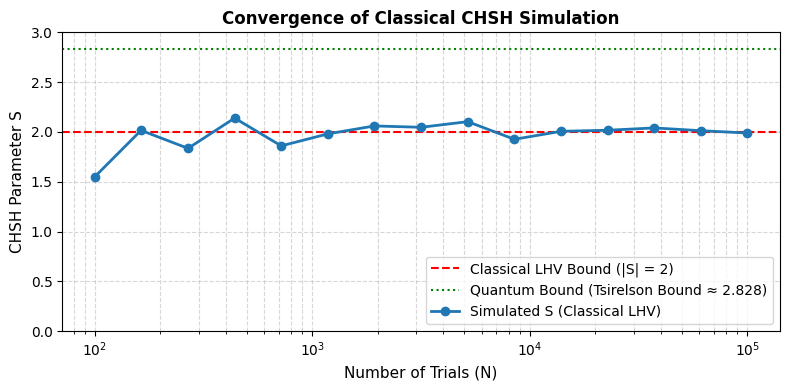

In [7]:
trial_counts = np.logspace(2, 5, 15, dtype=int)
s_values = []

for N in trial_counts:
    S_val, _ = simulate_classical_experiment(n_trials=N)
    s_values.append(S_val)

# Plotting convergence
plt.figure(figsize=(8, 4), dpi=100)
plt.axhline(y=2.0, color='r', linestyle='--', label='Classical LHV Bound (|S| = 2)')
plt.axhline(y=2*np.sqrt(2), color='g', linestyle=':', label='Quantum Bound (Tsirelson Bound ≈ 2.828)')

plt.plot(trial_counts, s_values, 'o-', color='#1f77b4', linewidth=2, label='Simulated S (Classical LHV)')
plt.xscale('log')
plt.ylim(0, 3.0)
plt.xlabel('Number of Trials (N)', fontsize=11)
plt.ylabel('CHSH Parameter S', fontsize=11)
plt.title('Convergence of Classical CHSH Simulation', fontsize=12, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Quantum Mechanical Model (Qiskit Simulation)

In this section, we replace local hidden variables with quantum entanglement. We simulate the CHSH experiment using a two-qubit quantum circuit implemented in **Qiskit**.

## 1. State Preparation and Projective Measurement via Basis Rotations
We prepare the maximally entangled singlet state $|\Psi^-\rangle$:

$$|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$$

In Qiskit, measurements are natively performed in the computational $Z$-basis ($\{|0\rangle, |1\rangle\}$). Measuring along an arbitrary axis $\theta$ is achieved by applying a rotation $R_y(-\theta)$ prior to measurement:

$$\text{Quantum Expectation Value: } E(a, b) = -\cos(a - b)$$

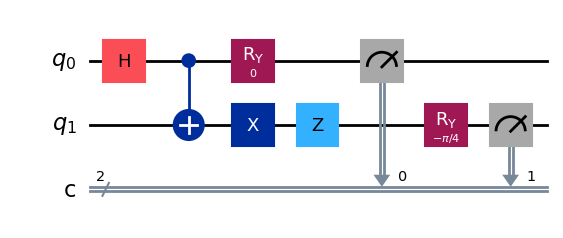

In [19]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from tqdm import tqdm

# Initialize Aer simulator
simulator = AerSimulator()

def create_bell_circuit(theta_a: float, theta_b: float) -> QuantumCircuit:
    """
    Prepares the singlet state and performs projective measurements along directions 
    theta_a (Alice, qubit 0) and theta_b (Bob, qubit 1).
    """
    qc = QuantumCircuit(2, 2)
    
    # State preparation: Bell singlet state |\Psi-\rangle
    qc.h(0)
    qc.cx(0, 1)
    qc.x(1)
    qc.z(1)

    # Measurement directions via basis rotation
    qc.ry(-theta_a, 0)
    qc.ry(-theta_b, 1)
    qc.measure([0, 1], [0, 1])

    return qc

# Visualize the circuit for standard angle settings
demo_qc = create_bell_circuit(0.0, np.pi/4)
demo_qc.draw('mpl')

## 2. Extracting Quantum Correlators $E(a, b)$

The correlation function $E(a, b)$ is computed as the expected product of binary outcomes $A, B \in \{+1, -1\}$, where state $\vert{}0\rangle \to +1$ and $\vert{}1\rangle \to -1$.

In [20]:
def correlation(counts, shots):
    """
    Computes the correlation E(a,b) from measurement counts.
    Outcomes are encoded as: 0 -> +1, 1 -> -1.

    Note on Qiskit bit ordering: bitstring[0] is qubit 1 (Bob),
    bitstring[1] is qubit 0 (Alice).
    """
    corr = 0
    for bitstring, count in counts.items():
        b = 1 if bitstring[0] == '0' else -1
        a = 1 if bitstring[1] == '0' else -1
        corr += a * b * count / shots
    return corr

def get_E_quantum(theta_a: float, theta_b: float, shots: int = 10000) -> float:
    """
    Computes quantum expectation value E(a, b) by executing the circuit on AerSimulator.
    Theoretical value for singlet state: E(a, b) = -cos(a - b).
    """
    qc = create_bell_circuit(theta_a, theta_b)
    job = simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    return correlation(counts, shots)

# Test quantum correlation for parallel vs orthogonal settings
print(f"Quantum E(0, 0)      [Parallel]   = {get_E_quantum(0, 0):.4f}  (Expected: -1.0)")
print(f"Quantum E(0, pi/2)   [Orthogonal] = {get_E_quantum(0, np.pi/2):.4f}  (Expected: 0.0)")
print(f"Quantum E(0, pi/4)   [45 deg]     = {get_E_quantum(0, np.pi/4):.4f}  (Expected: -cos(pi/4) ≈ -0.7071)")

Quantum E(0, 0)      [Parallel]   = -1.0000  (Expected: -1.0)
Quantum E(0, pi/2)   [Orthogonal] = -0.0120  (Expected: 0.0)
Quantum E(0, pi/4)   [45 deg]     = -0.6930  (Expected: -cos(pi/4) ≈ -0.7071)


## 3. Quantum CHSH Calculation (Statistical Limit)

Using optimal CHSH angles:
- Alice: $a = 0$, $a' = \pi/2$
- Bob: $b = \pi/4$, $b' = -\pi/4$

We compute $S$ in the statistical limit (evaluating four large batches of circuit runs).

In [21]:
def chsh_quantum(a=0.0, ap=np.pi/2, b=np.pi/4, bp=-np.pi/4, shots=10000) -> float:
    """
    Calculates the CHSH S value using quantum simulation in the statistical limit.
    """
    E_ab   = get_E_quantum(a, b, shots)
    E_apb  = get_E_quantum(ap, b, shots)
    E_abp  = get_E_quantum(a, bp, shots)
    E_apbp = get_E_quantum(ap, bp, shots)

    S = abs(E_ab + E_apb + E_abp - E_apbp)
    
    print(f"E(a, b)   = {E_ab:+.4f}")
    print(f"E(a', b)  = {E_apb:+.4f}")
    print(f"E(a, b')  = {E_abp:+.4f}")
    print(f"E(a', b') = {E_apbp:+.4f}")
    
    return S

print("--- Quantum Statistical Limit Evaluation ---")
S_qu = chsh_quantum()
print(f"\nQuantum CHSH S Parameter: {S_qu:.4f}")
print(f"Violation of Classical Bound (|S| <= 2): {S_qu > 2.0}")
print(f"Theoretical Tsirelson Bound: {2 * np.sqrt(2):.4f}")

--- Quantum Statistical Limit Evaluation ---
E(a, b)   = -0.7058
E(a', b)  = -0.7018
E(a, b')  = -0.7070
E(a', b') = +0.6976

Quantum CHSH S Parameter: 2.8122
Violation of Classical Bound (|S| <= 2): True
Theoretical Tsirelson Bound: 2.8284


## 4. Quantum Trial-by-Trial Laboratory Simulation

Now we simulate an event-by-event laboratory protocol where Alice and Bob randomly choose their measurement angles for each individual pair emission.

In [22]:
def simulate_quantum_experiment(n_trials=10000, shots_per_trial=1,
                               a=0.0, ap=np.pi/2, b=np.pi/4, bp=-np.pi/4,
                               print_corr=True):
    """
    Simulates trial-by-trial quantum CHSH experiment with random basis selection.
    """
    sums   = {'a_b': 0, 'a_bp': 0, 'ap_b': 0, 'ap_bp': 0}
    counts = {'a_b': 0, 'a_bp': 0, 'ap_b': 0, 'ap_bp': 0}

    print(f"Running {n_trials} quantum laboratory experiments...")
    for _ in tqdm(range(n_trials)):
        alice_angle = np.random.choice([a, ap])
        bob_angle   = np.random.choice([b, bp])

        alice_key = 'a' if alice_angle == a else 'ap'
        bob_key   = 'b' if bob_angle == b else 'bp'
        key = f"{alice_key}_{bob_key}"

        qc = create_bell_circuit(alice_angle, bob_angle)
        job = simulator.run(qc, shots=shots_per_trial)
        trial_counts = job.result().get_counts()

        for bitstring, count in trial_counts.items():
            b_out = 1 if bitstring[0] == '0' else -1
            a_out = 1 if bitstring[1] == '0' else -1
            sums[key]   += a_out * b_out * count
            counts[key] += count

    E_ab   = sums['a_b']   / counts['a_b']
    E_abp  = sums['a_bp']  / counts['a_bp']
    E_apb  = sums['ap_b']  / counts['ap_b']
    E_apbp = sums['ap_bp'] / counts['ap_bp']

    if print_corr:
        print(f"\nE(a,b)   = {E_ab:.4f}")
        print(f"E(a,b')  = {E_abp:.4f}")
        print(f"E(a',b)  = {E_apb:.4f}")
        print(f"E(a',b') = {E_apbp:.4f}")

    S = abs(E_ab + E_apb + E_abp - E_apbp)
    return S

S_qu_exp = simulate_quantum_experiment(n_trials=10000)
print(f"\nFinal S (Quantum Laboratory Protocol): {S_qu_exp:.4f}")

Running 10000 quantum laboratory experiments...


100%|██████████| 10000/10000 [00:09<00:00, 1073.94it/s]


E(a,b)   = -0.7210
E(a,b')  = -0.6839
E(a',b)  = -0.7361
E(a',b') = 0.7285

Final S (Quantum Laboratory Protocol): 2.8694
